# Vibrational Density of States (VDOS) Tutorial

The vibrational density of states can be obtained from the power spectrum of the atomic velocities, or equivalently
from the Fourier transform of the velocity autocorrelation function (VACF). The velocities must be the true time
derivatives of the positions, so the production run has to be **microcanonical (NVE)**: a thermostat (Nose-Hoover or
Langevin) rescales or perturbs the velocities and distorts the spectrum.

This notebook covers:

1. Thermalising a glass at 300 K in NVT
2. An NVE production run with `md_simulation(..., nve=True)`, dumping velocities every 5 fs
3. Checking energy conservation
4. Labelling atoms by element, oxygen class and Q$^n$ with `classify_vibrational_groups`
5. The mass-weighted VACF
6. The total VDOS with `compute_vdos_from_velocities`
7. Partial VDOS by element, oxygen class and Q$^n$ with `compute_partial_vdos`
8. Normalisation, centre-of-mass removal, single groups and large (float32, memory-mapped) trajectories
9. Band positions in THz, cm$^{-1}$ and meV with `convert_frequency`
10. Comparison with literature potentials and experiment

Units: positions in Å, time in fs (frequencies in THz), energies in eV. Velocities returned by `md_simulation`
are in Å/fs.

The total and partial VDOS, the atom groups and the unit conversion come from amorphouspy. The VACF and the block
averaging are still written inline with numpy; library functions for the VACF, a windowed spectrum and block
averaging will be added to amorphouspy later.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read

import amorphouspy as am

## Setup

A 300-atom SiO$_2$ glass and the PMMCS potential. The run lengths are kept short so the notebook runs in a few
minutes; production VDOS calculations should use longer NVE runs and average over several blocks.

In [2]:
glass = read("data/SiO2_glass_300_atoms.xyz")
potential = am.generate_potential(am.get_structure_dict({"SiO2": 100}, target_atoms=9), potential_type="pmmcs")
print(glass)

Atoms(symbols='O200Si100', pbc=True, cell=[[16.48757572410817, 3.0287185254343006e-15, 3.028718525434301e-15], [-2.019145683487156e-15, 16.487575723, 3.0287185252307334e-15], [-2.0191456834871554e-15, -2.019145683487156e-15, 16.487575723]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


## Step 1 — Thermalise at 300 K (NVT)

The NVE run starts from the velocities carried by the structure, so the glass is first equilibrated with a
thermostat. The returned structure carries the final velocities.

In [3]:
result_nvt = am.md_simulation(
    structure=glass,
    potential=potential,
    temperature_sim=300.0,
    production_steps=10_000,  # 10 ps
    n_dump=None,
    n_print_thermo=100,
    seed=42,
)
glass_300K = result_nvt["structure"]
print(f"Final NVT temperature: {result_nvt['result']['temperature'][-1]:.1f} K")

Final NVT temperature: 321.4 K


## Step 2 — NVE production

`nve=True` writes `fix ensemble all nve` (no thermostat, no barostat) and keeps the velocities of the input
structure (no `velocity create`). `temperature_sim` is unused in this mode. `nve` cannot be combined with
`pressure`, `pressure_end`, `temperature_end` or `langevin`.

Velocities are dumped every 5 fs, which resolves frequencies up to the Nyquist limit of 100 THz (the highest
Si–O stretching modes lie near 35 THz).

In [4]:
dump_every = 5  # MD steps
timestep_fs = 1.0

result_nve = am.md_simulation(
    structure=glass_300K,
    potential=potential,
    timestep=timestep_fs,
    production_steps=100_000,  # 100 ps
    n_dump=dump_every,
    n_print_thermo=dump_every,
    nve=True,
)
nve = result_nve["result"]
print(f"Mean NVE temperature: {np.mean(nve['temperature']):.1f} K")

Mean NVE temperature: 309.2 K


## Step 3 — Energy conservation

In NVE the total energy must be conserved. The drift per atom per picosecond is a quick check of the timestep
and the potential cutoffs.

Total-energy drift: 0.0002 meV/atom/ps, fluctuation (std): 0.0102 meV/atom


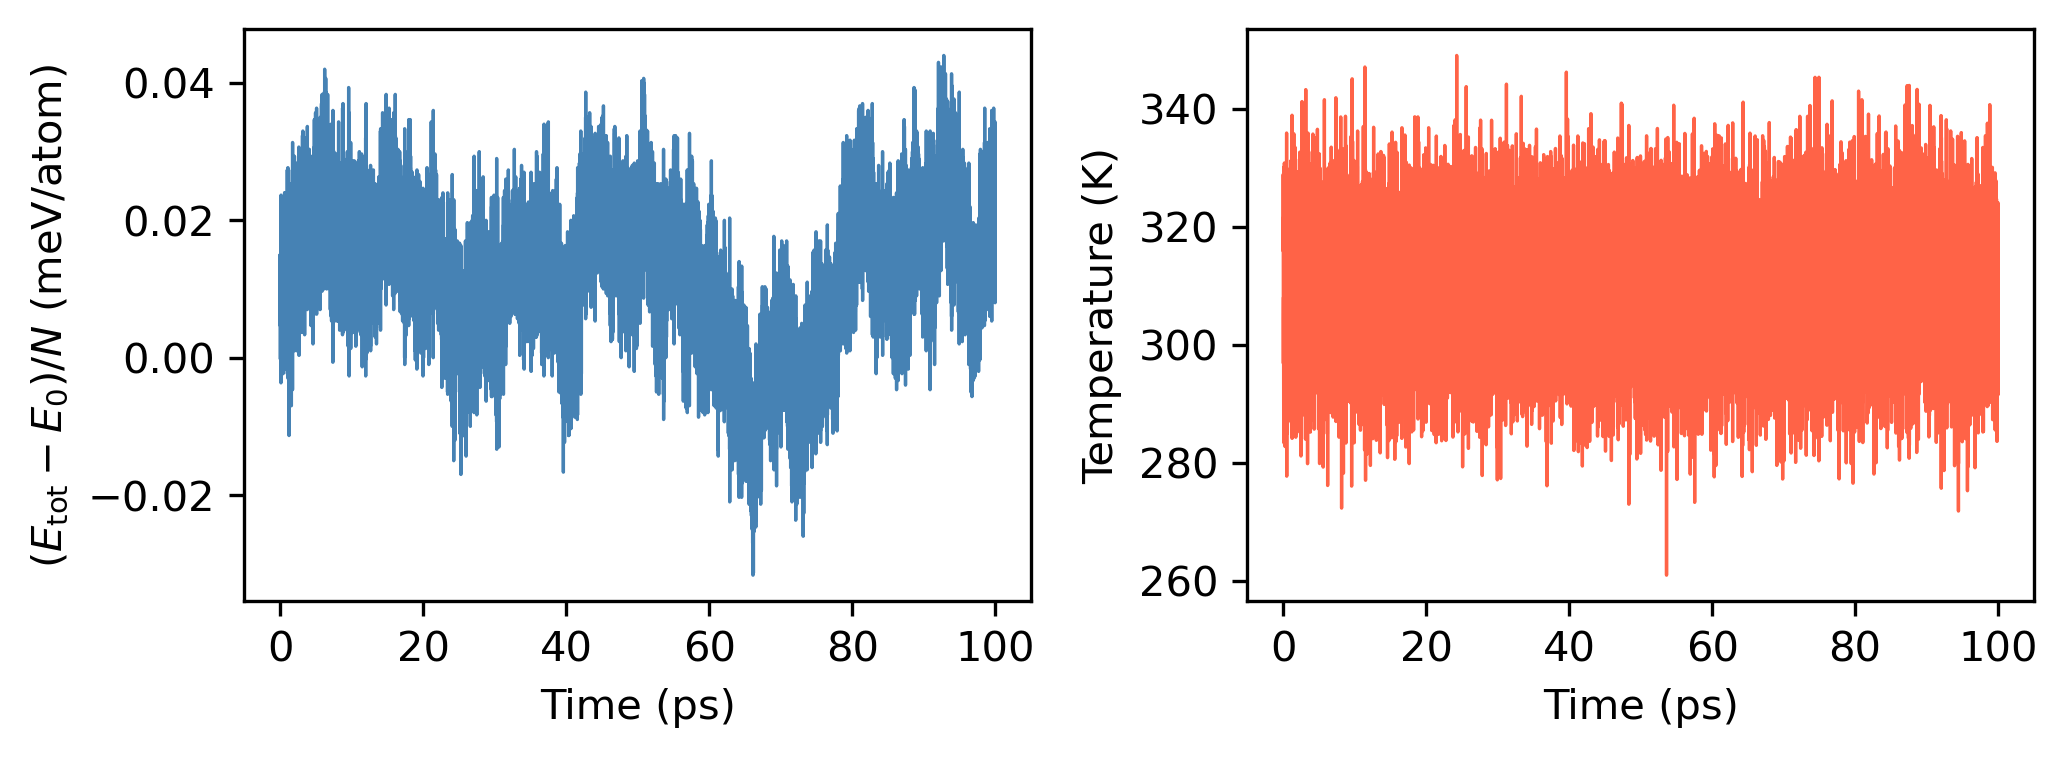

In [5]:
time_ps = np.asarray(nve["steps"]) * timestep_fs * 1e-3
e_tot = np.asarray(nve["energy_tot"])
n_atoms = len(glass)

drift = (e_tot[-1] - e_tot[0]) / n_atoms / (time_ps[-1] - time_ps[0]) * 1e3
fluct = np.std(e_tot) / n_atoms * 1e3
print(f"Total-energy drift: {drift:.4f} meV/atom/ps, fluctuation (std): {fluct:.4f} meV/atom")

_fig, axes = plt.subplots(1, 2, figsize=(3.5 * 2, 3.5 / 1.3333), dpi=300)
axes[0].plot(time_ps, (e_tot - e_tot[0]) / n_atoms * 1e3, lw=0.8, color="steelblue")
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel(r"$(E_\mathrm{tot} - E_0)/N$ (meV/atom)")
axes[1].plot(time_ps, nve["temperature"], lw=0.8, color="tomato")
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Temperature (K)")
plt.tight_layout()
plt.show()

A structure without velocities is rejected, so a forgotten equilibration cannot pass silently:

In [6]:
cold = glass.copy()
cold.set_velocities(np.zeros((len(cold), 3)))
try:
    am.md_simulation(structure=cold, potential=potential, production_steps=10, nve=True)
except ValueError as exc:
    print(f"ValueError: {exc}")

ValueError: nve with initial_temperature 0 needs a structure that carries non-zero velocities.


## Step 4 — Atom groups

`classify_vibrational_groups` labels every atom three ways, each a mapping from label to the 0-based positions of
the atoms in the structure:

- `"element"`: chemical symbol
- `"oxygen"`: bridging (`O_BO`), non-bridging (`O_NBO`), free (`O_free`) and tricluster (`O_tri`) oxygen
- `"qn"`: network former and its number of bridging oxygens (`Si_Q4`, ...), from `compute_qn_per_atom`

Without explicit arguments the network formers and the former–O cutoffs are derived from the composition and the
first minimum of the RDF, as in `analyze_structure`. Empty groups are omitted. The labels below are used to select
atoms for the partial VACF and VDOS.

In [7]:
groups = am.classify_vibrational_groups(glass_300K)
for grouping, labels in groups.items():
    counts = ", ".join(f"{label}: {len(indices)}" for label, indices in labels.items())
    print(f"{grouping:>8}: {counts}")

 element: O: 200, Si: 100
  oxygen: O_BO: 199, O_NBO: 1
      qn: Si_Q3: 2, Si_Q4: 98


/Users/achrafatila/Documents/Workflows/amorphouspy/amorphouspy/src/amorphouspy/properties/vibrational.py:155: UserWarning: r_max=10.0000 Å exceeds half the smallest perpendicular cell height (8.2438 Å). r_max has been automatically adjusted to 8.0 Å (largest integer not exceeding the limit).
  r, rdfs, _cumcn = compute_rdf(structure, r_max=10.0, n_bins=500)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Step 5 — Velocity autocorrelation function

The mass-weighted, normalised VACF is

$$C(t) = \frac{\sum_i m_i \langle \mathbf{v}_i(0)\cdot\mathbf{v}_i(t)\rangle}{\sum_i m_i \langle \mathbf{v}_i^2\rangle},$$

averaged over all time origins. It is computed with FFTs (Wiener–Khinchin theorem); zero padding to twice the
trajectory length avoids circular wrap-around. Per-element contributions use the same normalisation, so the
partial VACFs (and VDOS) sum exactly to the total.

velocities shape: (20001, 300, 3)
Mean kinetic temperature from dumped velocities: 309.2 K
C(0) = 1.000000


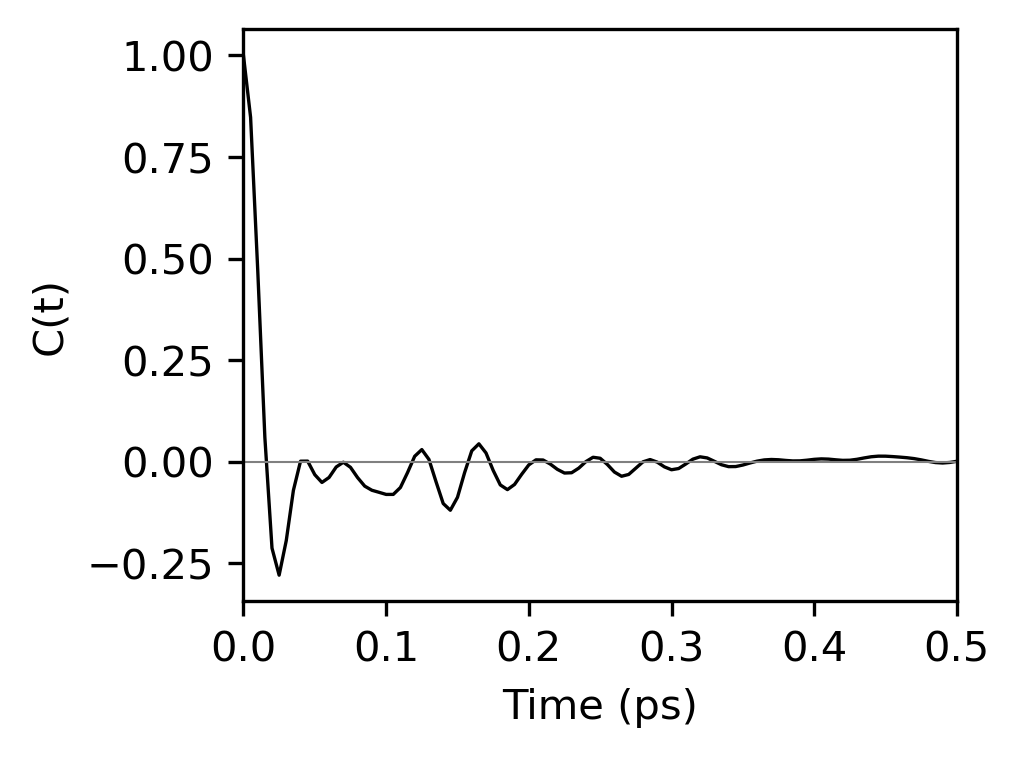

In [8]:
velocities = np.asarray(nve["velocities"])  # (n_frames, n_atoms, 3), Å/fs
masses = glass.get_masses()  # amu
n_frames = velocities.shape[0]
dt_ps = dump_every * timestep_fs * 1e-3
print("velocities shape:", velocities.shape)

# Consistency check: kinetic temperature from the dumped velocities (LAMMPS uses 3N - 3 degrees of freedom).
amu_A2_fs2_to_eV = 103.6427
k_B = 8.617333e-5  # eV/K
kinetic = 0.5 * np.einsum("i,fij->f", masses, velocities**2) * amu_A2_fs2_to_eV
t_kin = 2 * kinetic / ((3 * n_atoms - 3) * k_B)
print(f"Mean kinetic temperature from dumped velocities: {t_kin.mean():.1f} K")


def autocorrelation(signal: np.ndarray) -> np.ndarray:
    """Time-origin-averaged autocorrelation along axis 0 for every column, via zero-padded FFT."""
    n = signal.shape[0]
    spectrum = np.fft.rfft(signal, n=2 * n, axis=0)
    acf = np.fft.irfft(spectrum * spectrum.conj(), axis=0)[:n]
    return acf / (n - np.arange(n))[:, None]


# Per-atom autocorrelation summed over x, y, z: shape (n_frames, n_atoms)
acf_atoms = autocorrelation(velocities.reshape(n_frames, -1)).reshape(n_frames, n_atoms, 3).sum(axis=2)
n_lags = n_frames // 2  # only use lags with at least n/2 time origins
weighted = acf_atoms[:n_lags] * masses
norm = weighted[0].sum()
vacf = {"total": weighted.sum(axis=1) / norm}
for element in ("Si", "O"):
    vacf[element] = weighted[:, groups["element"][element]].sum(axis=1) / norm
lag_ps = np.arange(n_lags) * dt_ps
print(f"C(0) = {vacf['total'][0]:.6f}")

_fig, ax = plt.subplots(figsize=(3.5, 3.5 / 1.3333), dpi=300)
ax.plot(lag_ps, vacf["total"], lw=0.8, color="black")
ax.axhline(0.0, color="gray", lw=0.5)
ax.set_xlim(0, 0.5)
ax.set_xlabel("Time (ps)")
ax.set_ylabel("C(t)")
plt.tight_layout()
plt.show()

## Step 6 — Total VDOS

The VDOS is the mass-weighted velocity power spectrum

$$g(\nu) \propto \sum_i m_i \sum_{\alpha=x,y,z} \left|\tilde v_{i\alpha}(\nu)\right|^2,$$

where $\tilde v_{i\alpha}(\nu)$ is the Fourier transform of the velocity component over the trajectory. By the
Wiener–Khinchin theorem this is the Fourier transform of the (unnormalised) mass-weighted VACF.

`am.compute_vdos_from_velocities(velocities, masses, dt_fs)` removes the mass-weighted centre-of-mass velocity
from every frame, accumulates the spectrum over chunks of atoms (so memory stays near the input size), and
normalises it to $\int g(\nu)\, d\nu = 1$ (units THz$^{-1}$). `dt_fs` is the time between dumped frames, not the
MD timestep. No window or zero padding is applied: the frequency resolution is $1/(n_\mathrm{frames}\,\Delta t)$,
about 0.1 THz for this 10 ps run, and the spectrum of a single block is noisy and shows leakage. The secondary
axis uses `am.convert_frequency` to show wavenumbers.

10 blocks of 2000 frames, 1 trailing frame(s) dropped
1001 frequencies, resolution 0.1000 THz, Nyquist 100.0 THz
Integral of total VDOS: 1.000000


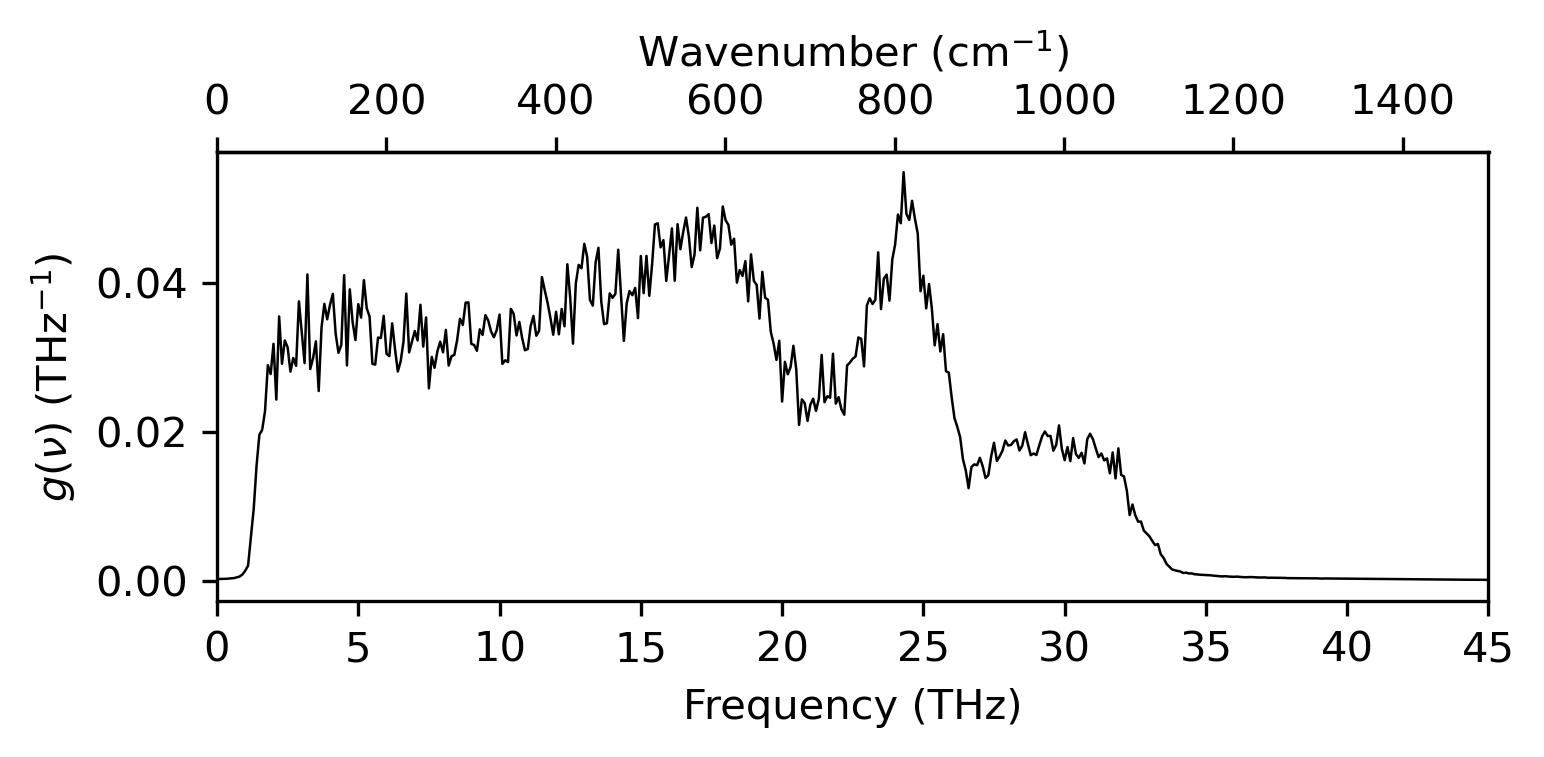

In [13]:
dt_fs = dump_every * timestep_fs
block_ps = 10.0

block_frames = round(block_ps * 1e3 / dt_fs)  # 2000 frames per 10 ps block at 5 fs
n_blocks = velocities.shape[0] // block_frames
dropped = velocities.shape[0] - n_blocks * block_frames
print(f"{n_blocks} blocks of {block_frames} frames, {dropped} trailing frame(s) dropped")

block_vdos = []
for b in range(n_blocks):
    block = velocities[b * block_frames : (b + 1) * block_frames]
    freq_thz, g = am.compute_vdos_from_velocities(block, masses, dt_fs)
    block_vdos.append(g)
block_vdos = np.array(block_vdos)  # (n_blocks, n_freq)

g_mean = block_vdos.mean(axis=0)
g_sem = block_vdos.std(axis=0, ddof=1) / np.sqrt(n_blocks)  # block standard error


print(f"{len(freq_thz)} frequencies, resolution {freq_thz[1]:.4f} THz, Nyquist {freq_thz[-1]:.1f} THz")
print(f"Integral of total VDOS: {np.trapezoid(g_mean, freq_thz):.6f}")

_fig, ax = plt.subplots(figsize=(3.5 * 1.5, 3.5 / 1.3333), dpi=300)
ax.plot(freq_thz, g_mean, lw=0.6, color="black")
ax.set_xlim(0, 45)
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel(r"$g(\nu)$ (THz$^{-1}$)")
secax = ax.secondary_xaxis(
    "top",
    functions=(lambda x: am.convert_frequency(x, "THz", "cm-1"), lambda x: am.convert_frequency(x, "cm-1", "THz")),
)
secax.set_xlabel(r"Wavenumber (cm$^{-1}$)")
plt.tight_layout()
plt.show()

## Step 7 — Partial VDOS

A group's partial VDOS is the same power spectrum summed over the atoms of the group only.
`am.compute_partial_vdos(velocities, masses, dt_fs, groups)` takes the `groups` from Step 4 directly and transforms
every atom once, however many groups it belongs to. It removes the centre-of-mass velocity of the whole system and
scales every partial by the normalisation of the total, so partials over any complete set of groups add up to the
total VDOS: Si + O gives the total, the oxygen classes give the O partial, and the Si Q$^n$ species give the Si
partial. It uses the same implementation as `compute_vdos_from_velocities` (which also accepts `indices=` for a
single group). The partials are averaged over the same blocks as the total. Groups with only a few atoms are small
and noisy.

max |sum(element) - total|: 1.39e-17
max |sum(oxygen) - O|:      1.04e-17
max |sum(qn) - Si|:         6.94e-18


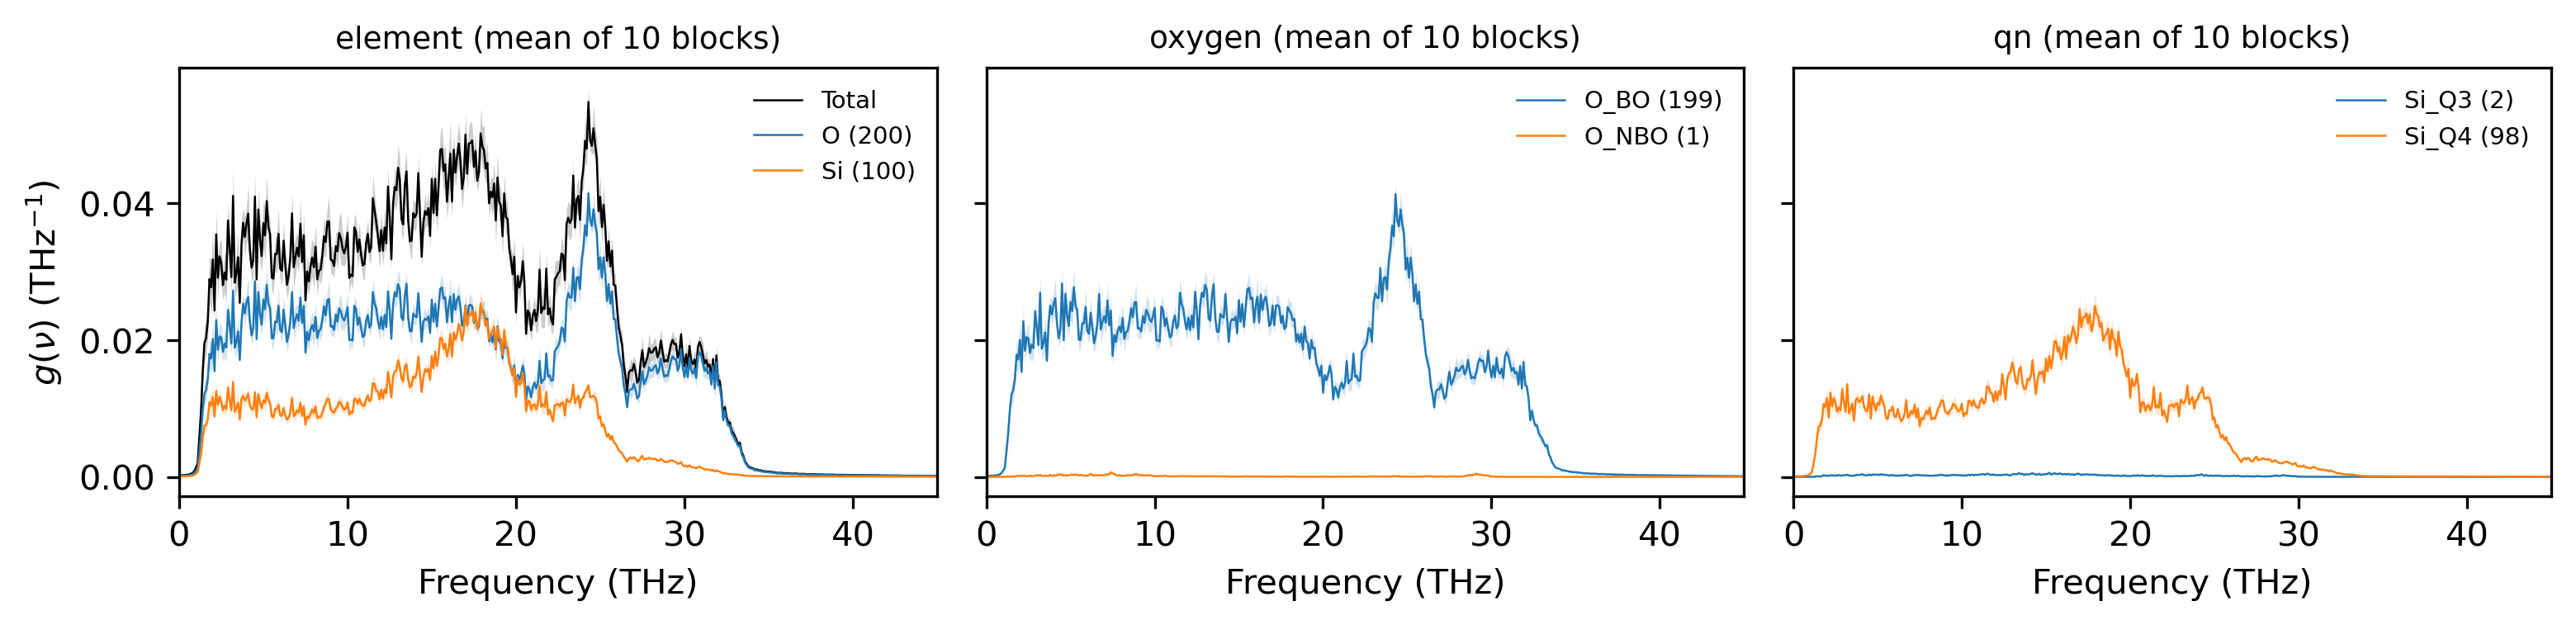

In [14]:
# Same blocks as the total VDOS; the groups from Step 4 are reused for every block.
block_partial = {grouping: {label: [] for label in labels} for grouping, labels in groups.items()}
for b in range(n_blocks):
    block = velocities[b * block_frames : (b + 1) * block_frames]
    _, block_groups = am.compute_partial_vdos(block, masses, dt_fs, groups)
    for grouping, labels in block_groups.items():
        for label, values in labels.items():
            block_partial[grouping][label].append(values)

partial = {
    grouping: {label: np.mean(values, axis=0) for label, values in labels.items()}
    for grouping, labels in block_partial.items()
}
partial_sem = {
    grouping: {label: np.std(values, axis=0, ddof=1) / np.sqrt(n_blocks) for label, values in labels.items()}
    for grouping, labels in block_partial.items()
}

print(f"max |sum(element) - total|: {np.abs(sum(partial['element'].values()) - g_mean).max():.2e}")
print(f"max |sum(oxygen) - O|:      {np.abs(sum(partial['oxygen'].values()) - partial['element']['O']).max():.2e}")
print(f"max |sum(qn) - Si|:         {np.abs(sum(partial['qn'].values()) - partial['element']['Si']).max():.2e}")

_fig, axes = plt.subplots(1, 3, figsize=(3.5 * 3, 3.5 / 1.3333), dpi=300, sharey=True)
axes[0].plot(freq_thz, g_mean, lw=0.6, color="black", label="Total")
axes[0].fill_between(freq_thz, g_mean - g_sem, g_mean + g_sem, color="black", alpha=0.2, lw=0)
for ax, grouping in zip(axes, ("element", "oxygen", "qn"), strict=True):
    for label, values in partial[grouping].items():
        sem = partial_sem[grouping][label]
        (line,) = ax.plot(freq_thz, values, lw=0.6, label=f"{label} ({len(groups[grouping][label])})")
        ax.fill_between(freq_thz, values - sem, values + sem, color=line.get_color(), alpha=0.2, lw=0)
    ax.set_xlim(0, 45)
    ax.set_xlabel("Frequency (THz)")
    ax.set_title(f"{grouping} (mean of {n_blocks} blocks)", fontsize=9)
    ax.legend(frameon=False, fontsize=7)
axes[0].set_ylabel(r"$g(\nu)$ (THz$^{-1}$)")
plt.tight_layout()
plt.show()

## Step 8 — Normalisation, centre of mass and large trajectories

`compute_vdos_from_velocities` and `compute_partial_vdos` share one implementation and take the same keyword
options. The cell below uses the first 10 ps block and checks each option against an independent quantity.

- `normalization="unit"` (default): $\int g\,d\nu = 1$ (THz$^{-1}$).
- `normalization="3N"`: the total integrates to $3N$, the number of degrees of freedom. A partial integrates to $3N$
  times its share of the kinetic energy, which by equipartition is close to $3N_\mathrm{group}$.
- `normalization="none"`: the power spectral density $S(\nu) = (2\Delta t/N_\mathrm{frames}) \sum_i m_i
  \sum_\alpha |\tilde v_{i\alpha}(\nu)|^2$ in amu (Å/fs)$^2$ ps. Its integral is the time average of
  $\sum_i m_i |\mathbf v_i|^2$ (Parseval's theorem, exact for an even number of frames), i.e. twice the kinetic
  energy, so it gives the kinetic temperature without any other input.
- `indices=...`: the partial VDOS of one group, identical to the corresponding entry of `compute_partial_vdos`.
- `remove_com=True` (default) subtracts the centre-of-mass velocity of the whole system,
  $\mathbf v_\mathrm{COM}(t) = \sum_i m_i \mathbf v_i(t) / \sum_i m_i$, from every frame. A drift of the whole box
  then leaves the spectrum unchanged; with `remove_com=False` it appears at zero frequency.
- Large trajectories: velocities are processed in chunks of atoms, float32 input is transformed in single precision
  without a float64 copy, and a memory-mapped array (`np.load(path, mmap_mode="r")`) is read from disk chunk by
  chunk, so the full trajectory never has to be in memory.

"3N": integral of the total 900.00, 3N = 900
       O: integral  602.25, 3 N_O = 600
      Si: integral  297.75, 3 N_Si = 300
"none": T from the spectrum 309.22 K, from the dumped velocities 309.22 K
indices: max |O_BO from indices - O_BO from compute_partial_vdos| = 4.9e-17
remove_com=True:  max |drifting - original| = 1.4e-17
remove_com=False: g(0) = 0.51 THz^-1 (original g(0) = 2.22e-04 THz^-1)
float32 memmap (7.2 MB on disk): max |difference| / max g = 6.8e-08


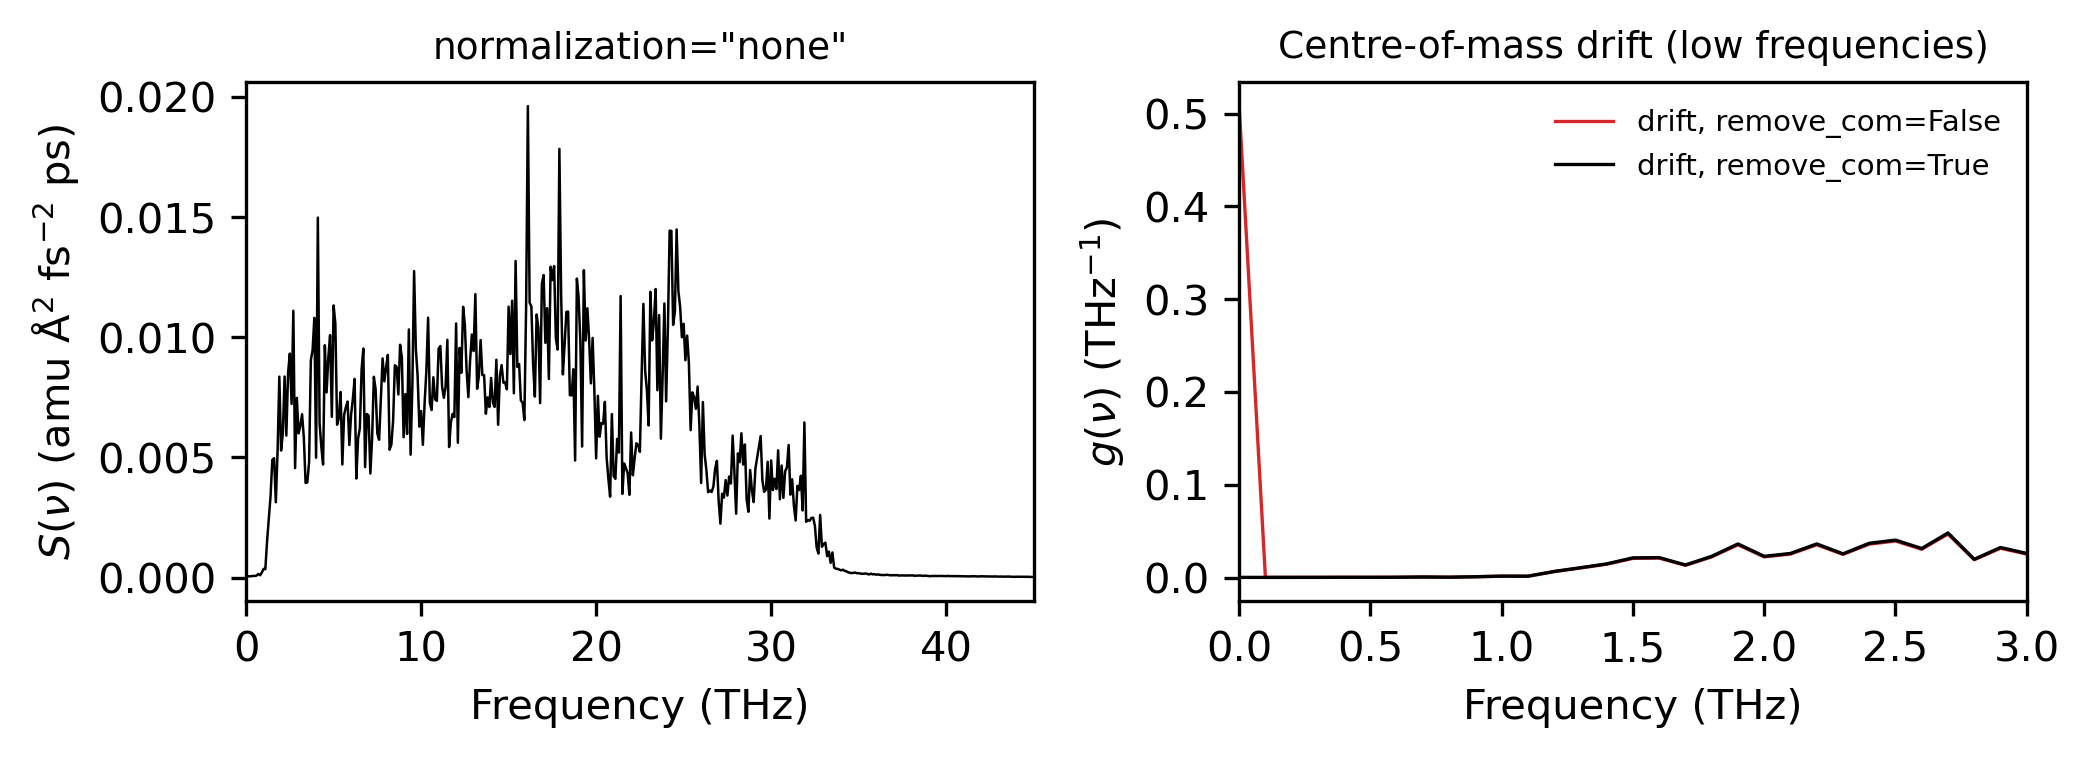

In [15]:
block = velocities[:block_frames]
_, g_block = am.compute_vdos_from_velocities(block, masses, dt_fs)

# "3N": degrees of freedom, and equipartition for the partials
_, g_3n = am.compute_vdos_from_velocities(block, masses, dt_fs, normalization="3N")
_, partial_3n = am.compute_partial_vdos(block, masses, dt_fs, groups, normalization="3N")
print(f'"3N": integral of the total {np.trapezoid(g_3n, freq_thz):.2f}, 3N = {3 * n_atoms}')
for label, values in partial_3n["element"].items():
    print(
        f"      {label:>2}: integral {np.trapezoid(values, freq_thz):7.2f}, 3 N_{label} = {3 * len(groups['element'][label])}"
    )

# "none": the integral of the spectral density is <sum m v^2>, which gives the kinetic temperature
_, psd = am.compute_vdos_from_velocities(block, masses, dt_fs, normalization="none")
mean_mv2 = np.trapezoid(psd, freq_thz)  # amu (Å/fs)^2, centre of mass removed
t_from_psd = mean_mv2 * amu_A2_fs2_to_eV / ((3 * n_atoms - 3) * k_B)
print(f'"none": T from the spectrum {t_from_psd:.2f} K, from the dumped velocities {t_kin[:block_frames].mean():.2f} K')

# indices: one group without building a sub-trajectory
_, partial_unit = am.compute_partial_vdos(block, masses, dt_fs, groups)
_, g_bo = am.compute_vdos_from_velocities(block, masses, dt_fs, indices=groups["oxygen"]["O_BO"])
print(
    f"indices: max |O_BO from indices - O_BO from compute_partial_vdos| = {np.abs(g_bo - partial_unit['oxygen']['O_BO']).max():.1e}"
)

# remove_com: add a uniform drift of 0.001 Å/fs to every atom
drifting = block + np.array([1e-3, 0.0, 0.0])
_, g_drift = am.compute_vdos_from_velocities(drifting, masses, dt_fs)
_, g_drift_kept = am.compute_vdos_from_velocities(drifting, masses, dt_fs, remove_com=False)
print(f"remove_com=True:  max |drifting - original| = {np.abs(g_drift - g_block).max():.1e}")
print(f"remove_com=False: g(0) = {g_drift_kept[0]:.2f} THz^-1 (original g(0) = {g_block[0]:.2e} THz^-1)")

# float32 trajectory on disk, read chunk by chunk through a memory map
with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "velocities_block.npy"
    np.save(path, block.astype(np.float32))
    mapped = np.load(path, mmap_mode="r")
    _, g_mapped = am.compute_vdos_from_velocities(mapped, masses, dt_fs)
    print(
        f"float32 memmap ({mapped.nbytes / 1e6:.1f} MB on disk): max |difference| / max g = {np.abs(g_mapped - g_block).max() / g_block.max():.1e}"
    )
    del mapped

_fig, axes = plt.subplots(1, 2, figsize=(3.5 * 2, 3.5 / 1.3333), dpi=300)
axes[0].plot(freq_thz, psd, lw=0.6, color="black")
axes[0].set_xlim(0, 45)
axes[0].set_xlabel("Frequency (THz)")
axes[0].set_ylabel(r"$S(\nu)$ (amu Å$^2$ fs$^{-2}$ ps)")
axes[0].set_title('normalization="none"', fontsize=9)
axes[1].plot(freq_thz, g_drift_kept, lw=0.8, color="tab:red", label="drift, remove_com=False")
axes[1].plot(freq_thz, g_drift, lw=0.8, color="black", label="drift, remove_com=True")
axes[1].set_xlim(0, 3)
axes[1].set_xlabel("Frequency (THz)")
axes[1].set_ylabel(r"$g(\nu)$ (THz$^{-1}$)")
axes[1].set_title("Centre-of-mass drift (low frequencies)", fontsize=9)
axes[1].legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

## Step 9 — Frequency units

`am.convert_frequency(values, from_unit, to_unit)` converts between THz, cm$^{-1}$, meV and rad/ps (scalars or
arrays). Below, approximate band positions of the total VDOS are reported in each unit. The single-block spectrum
fluctuates strongly from bin to bin, so each position is the maximum of a 1 THz running mean (11 bins) inside a
window around a band visible in the plot above. The smoothing is used only to locate the bands; these are rough
positions, not fitted peaks.

In [16]:
window_bins = 11  # 1.1 THz at 0.1 THz resolution
g_smooth = np.convolve(g_mean, np.ones(window_bins) / window_bins, mode="same")

windows_thz = {"Si-O-Si bending": (10.0, 21.0), "stretching I": (22.0, 27.0), "stretching II": (27.0, 34.0)}
print(f"{'band':>16} {'THz':>7} {'cm-1':>8} {'meV':>7} {'rad/ps':>8}")
for band, (low, high) in windows_thz.items():
    in_window = (freq_thz >= low) & (freq_thz <= high)
    peak_thz = freq_thz[in_window][np.argmax(g_smooth[in_window])]
    in_units = [am.convert_frequency(peak_thz, "THz", unit) for unit in ("cm-1", "meV", "rad/ps")]
    print(f"{band:>16} {peak_thz:7.2f} {in_units[0]:8.1f} {in_units[1]:7.2f} {in_units[2]:8.2f}")

            band     THz     cm-1     meV   rad/ps
 Si-O-Si bending   17.50    583.7   72.37   109.96
    stretching I   24.40    813.9  100.91   153.31
   stretching II   29.60    987.3  122.42   185.98


## Step 10 — Comparison with the literature

Fossati et al. (J. Am. Ceram. Soc. **104**, 1331 (2021), [doi:10.1111/jace.17549](https://doi.org/10.1111/jace.17549))
compare the VDOS of silica glass from several interatomic potentials with experimental data. The cell below loads
their Pedone and SHIK curves and the two experimental datasets (labelled "ref. 1" and "ref. 2" in their figure; see
the paper for the original sources), **digitized from the published figure** by pixel colour and stored in
`data/Fossati2021_SiO2_VDOS_*.dat`. The values are
approximate (about ±0.3 in DOS and ±0.5 meV in energy). Both digitized curves integrate to 1 over energy, the same
normalisation as `compute_vdos_from_velocities`, so the spectra are compared without rescaling: the VDOS in
THz$^{-1}$ is converted to (atom eV)$^{-1}$ with `convert_frequency`.

PMMCS is the Pedone potential, so this run should reproduce their Pedone curve. Differences can come from the system
size (300 atoms here), the quench history of the glass, and the temperature and run length of the NVE production;
those settings of the reference calculation are given in the paper, not here.

Integral over energy: SHIK 1.002, Pedone 1.000
Integral over energy, this work: 1.000


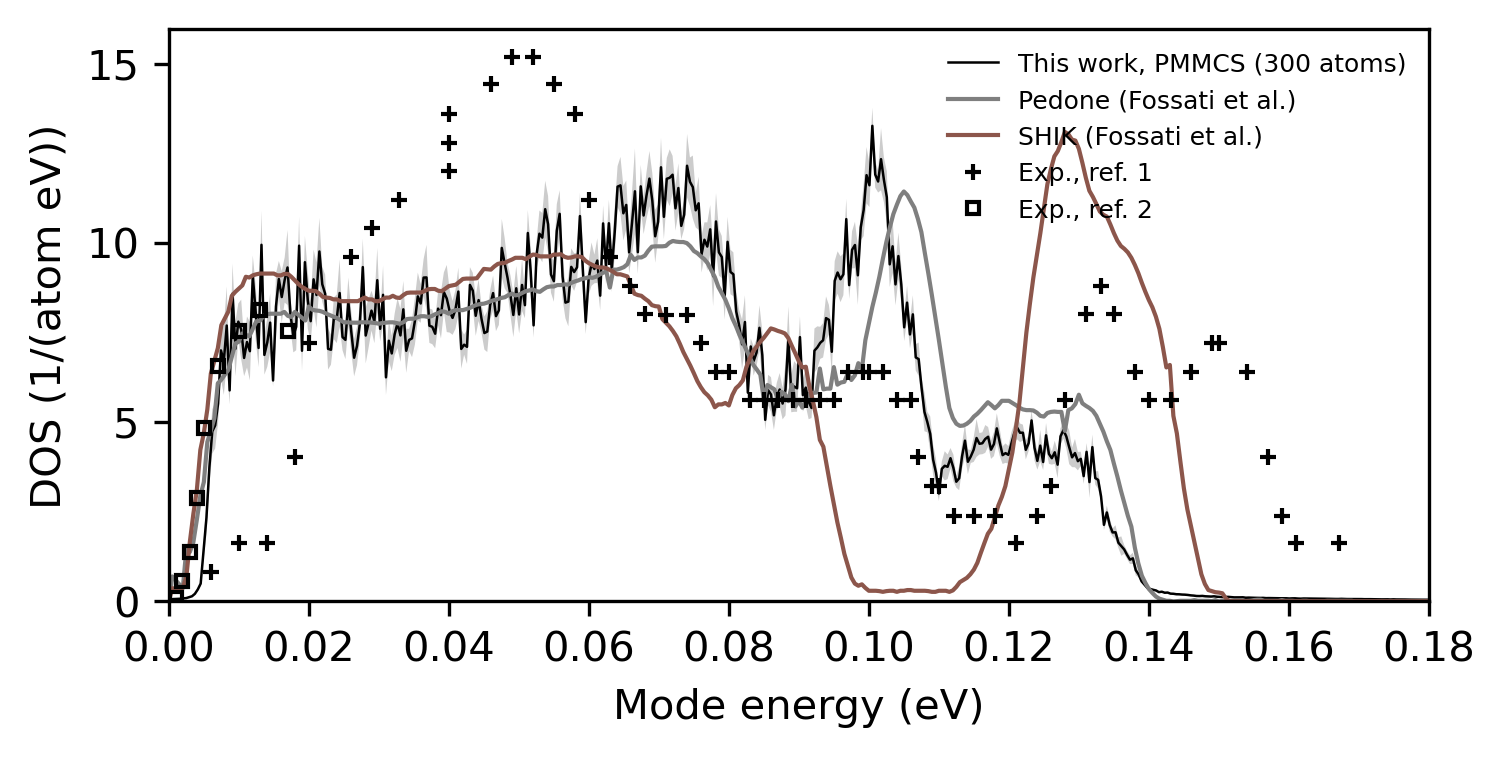

           This work: band maximum at 100.9 meV
  Pedone (digitized): band maximum at 105.0 meV


In [17]:
# Digitized from Fossati et al. (2021); provenance and accuracy are in the header of each file.
lit_energy_ev, lit_pedone, lit_shik = np.loadtxt("data/Fossati2021_SiO2_VDOS_Pedone_SHIK.dat", unpack=True)
lit_ref1 = np.loadtxt("data/Fossati2021_SiO2_VDOS_exp_ref1.dat")
lit_ref2 = np.loadtxt("data/Fossati2021_SiO2_VDOS_exp_ref2.dat")

print(
    f"Integral over energy: SHIK {np.trapezoid(lit_shik, lit_energy_ev):.3f}, Pedone {np.trapezoid(lit_pedone, lit_energy_ev):.3f}"
)

# This work: mean block VDOS in 1/THz -> 1/eV on an energy axis in eV.
ev_per_thz = am.convert_frequency(1.0, "THz", "meV") * 1e-3
energy_ev = am.convert_frequency(freq_thz, "THz", "meV") * 1e-3
g_ev, g_sem_ev = g_mean / ev_per_thz, g_sem / ev_per_thz
print(f"Integral over energy, this work: {np.trapezoid(g_ev, energy_ev):.3f}")

_fig, ax = plt.subplots(figsize=(3.5 * 1.5, 3.5 / 1.3333), dpi=300)
ax.fill_between(energy_ev, g_ev - g_sem_ev, g_ev + g_sem_ev, color="black", alpha=0.2, lw=0)
ax.plot(energy_ev, g_ev, lw=0.6, color="black", label=f"This work, PMMCS ({n_atoms} atoms)")
ax.plot(lit_energy_ev, lit_pedone, lw=1.0, color="tab:gray", label="Pedone (Fossati et al.)")
ax.plot(lit_energy_ev, lit_shik, lw=1.0, color="tab:brown", label="SHIK (Fossati et al.)")
ax.plot(*lit_ref1.T, "+", color="black", ms=4, label="Exp., ref. 1")
ax.plot(*lit_ref2.T, "s", mfc="none", color="black", ms=3, label="Exp., ref. 2")
ax.set_xlim(0, 0.18)
ax.set_ylim(bottom=0)
ax.set_xlabel("Mode energy (eV)")
ax.set_ylabel("DOS (1/(atom eV))")
ax.legend(frameon=False, fontsize=6)
plt.tight_layout()
plt.show()

# Position of the stretching band maximum near 0.1 eV (this work smoothed over ~1 THz, as in Step 8).
for label, energy, dos in [
    ("This work", energy_ev, g_smooth / ev_per_thz),
    ("Pedone (digitized)", lit_energy_ev, lit_pedone),
]:
    window = (energy >= 0.09) & (energy <= 0.115)
    print(f"{label:>20}: band maximum at {energy[window][np.argmax(dos[window])] * 1e3:.1f} meV")

For SiO$_2$ glass the experimental and ab initio spectra show a low-frequency band below ~5 THz, a broad band
around 12–15 THz (Si–O–Si bending), and Si–O stretching bands near 24 THz and 32–36 THz. Band positions and
intensities obtained with a classical potential such as PMMCS can be shifted with respect to these values; the
single 10 ps block used here is also noisy. Longer NVE runs averaged over several blocks are needed for
quantitative work.

## Quick Reference

| Step | Call | Ensemble |
|------|------|----------|
| Thermalise | `am.md_simulation(structure, potential, temperature_sim=T)` | NVT |
| Production | `am.md_simulation(result["structure"], potential, nve=True, n_dump=5)` | NVE |
| Velocities | `result["result"]["velocities"]`, shape `(n_frames, n_atoms, 3)`, Å/fs | — |
| Atom groups | `am.classify_vibrational_groups(structure)` | — |
| Total VDOS | `am.compute_vdos_from_velocities(velocities, masses, dt_fs)` | — |
| Partial VDOS | `am.compute_partial_vdos(velocities, masses, dt_fs, groups)` | — |
| One group | `am.compute_vdos_from_velocities(velocities, masses, dt_fs, indices=groups["qn"]["Si_Q4"])` | — |
| Options | `normalization="unit" \| "3N" \| "none"`, `remove_com=True` | — |
| Units | `am.convert_frequency(values, "THz", "cm-1")` | — |